# TEMPO — Full EM on Trajectories

**TEMPO** fits a mixture of $M$ regime-specific bases via EM.
Each unit of clustering is a **full spatiotemporal trajectory** $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$.

EM alternates between:
- **E-step**: recompute soft regime assignments $\gamma_{nm}$ from reconstruction errors
- **M-step**: update mixture weights $\pi_m$ and retrain bases with new $\gamma$

In [1]:
import sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from umap import UMAP

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from models.tempo import TEMPOTrainer, TEMPOConfig, pod_factory
from models.pod import PODConfig
from utils.datasets import load

if torch.backends.mps.is_available():   DEVICE = 'mps'
elif torch.cuda.is_available():         DEVICE = 'cuda'
else:                                   DEVICE = 'cpu'


def draw_cov_ellipse(ax, mean2d, cov2d, color, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h  = 2 * n_std * np.sqrt(np.abs(vals))
    ellipse = Ellipse(mean2d, w, h, angle=angle,
                      edgecolor=color, facecolor="none", lw=2, **kwargs)
    ax.add_patch(ellipse)

In [ ]:
nu_values = [0.001, 0.01, 0.1, 1.0]
N_samples  = 9000   # trajectories per nu

In [3]:
tensors, kappas = [], []

for nu in nu_values:
    data  = load(f"Burgers_Nu{nu}")
    u     = data["tensor"][:N_samples, :, :, 0]   # (N_samples, Nt, Nx)
    t_np  = data["t-coordinate"]                   # (Nt,)
    x_np  = data["x-coordinate"]                   # (Nx,)
    N, Nt, Nx = u.shape

    tensors.append(u.reshape(N, -1))               # (N, Nt*Nx)
    kappas.append(np.full(N, nu))                  # (N,)

s_np     = np.concatenate(tensors, axis=0)         # (N_total, Nt*Nx)
k_np_all = np.concatenate(kappas,  axis=0)         # (N_total,)

# spatiotemporal coordinate pairs (x, t) for each of Nt*Nx points
x_grid = torch.tensor(x_np, dtype=torch.float32)
t_grid = torch.tensor(t_np, dtype=torch.float32)
tt, xx = torch.meshgrid(t_grid, x_grid, indexing='ij')              # (Nt, Nx)
x_flat = torch.stack([xx.flatten(), tt.flatten()], dim=1)           # (Nt*Nx, 2)

s     = torch.tensor(s_np, dtype=torch.float32, device=DEVICE)      # (N_total, Nt*Nx)
x     = x_flat.to(DEVICE)                                           # (Nt*Nx, 2)
kappa = torch.tensor(k_np_all[:, None], dtype=torch.float32, device=DEVICE)

print(f"s={s.shape}, x={x.shape}, kappa={kappa.shape}")

s=torch.Size([3600, 25856]), x=torch.Size([25856, 2]), kappa=torch.Size([3600, 1])


In [4]:
print(f"s={s.shape}, x={x.shape}, kappa={kappa.shape}")

s=torch.Size([3600, 25856]), x=torch.Size([25856, 2]), kappa=torch.Size([3600, 1])


In [ ]:
cfg = TEMPOConfig(
    M=3,
    P_global=20,
    sigma2=0.1,
    max_em_iters=10,
    eps_skip=0.01,
    eps_large=0.1,
    eps_conv=0.005,
    basis_config=PODConfig(max_modes=32),
    basis_factory=pod_factory,
)

regime_colors = plt.cm.Set1(np.linspace(0, 0.8, cfg.M))

In [ ]:
trainer = TEMPOTrainer(cfg)
trainer.train(s, x, t=None, kappa=kappa)

POD | N=3600, Ny=25856 | max_modes=8, tol=1.0
  P=8 modes (100.00% variance threshold, needed 2689)
  mode  1: sigma=9.7722e+01  cumvar=91.24%  res_mse=3.5476e-02
  mode  2: sigma=1.0081e+01  cumvar=92.21%  res_mse=3.1545e-02
  mode  3: sigma=9.8696e+00  cumvar=93.14%  res_mse=2.7777e-02
  mode  4: sigma=7.1700e+00  cumvar=93.63%  res_mse=2.5789e-02
  mode  5: sigma=6.8473e+00  cumvar=94.08%  res_mse=2.3976e-02
  mode  6: sigma=6.4953e+00  cumvar=94.48%  res_mse=2.2344e-02
  mode  7: sigma=6.2785e+00  cumvar=94.86%  res_mse=2.0820e-02
  mode  8: sigma=5.0825e+00  cumvar=95.10%  res_mse=1.9820e-02
  done: final res_mse=1.9820e-02
POD | N=3600, Ny=25856 | max_modes=5, tol=0.9999
  P=5 modes (99.99% variance threshold, needed 199)
  mode  1: sigma=1.1888e+02  cumvar=98.90%  res_mse=3.5580e-02
  mode  2: sigma=3.4555e+00  cumvar=98.99%  res_mse=3.4862e-02
  mode  3: sigma=3.4259e+00  cumvar=99.07%  res_mse=3.4743e-02
  mode  4: sigma=3.2717e+00  cumvar=99.14%  res_mse=3.4647e-02
  mode  5:

### Results — EM regime structure

In [ ]:
N_viz = min(5632, len(s))
idx   = np.random.choice(len(s), N_viz, replace=False)

kappa_viz   = kappa[idx, 0].cpu().numpy()
alpha_viz   = trainer.alpha[idx].cpu().numpy()
hard_labels = trainer.gamma[idx].argmax(dim=1).cpu().numpy()
mu_np       = trainer.mu.cpu().numpy()   # (M, P_global)

UMAP of trajectory coefficients $\alpha^n \in \mathbb{R}^P$:

In [ ]:
reducer   = UMAP(n_neighbors=30, min_dist=0.0)
embedding = reducer.fit_transform(alpha_viz)
mu_umap   = reducer.transform(mu_np)

Visualization:

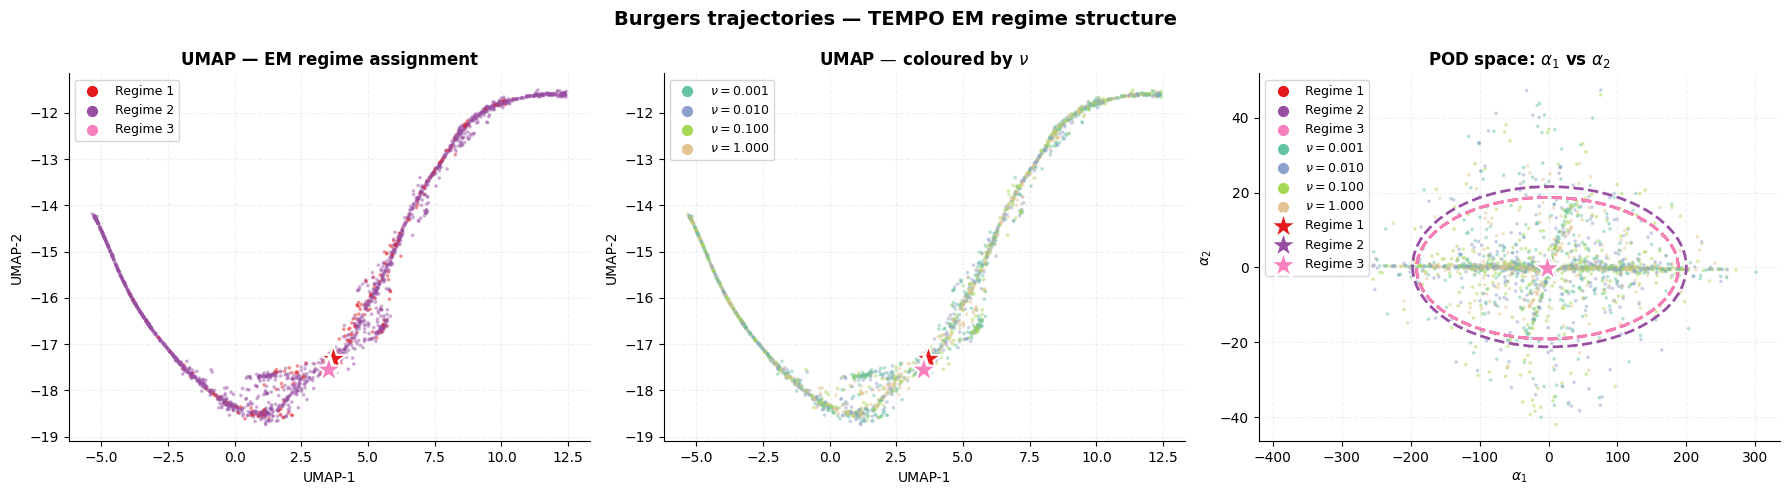

In [ ]:
nu_unique    = np.unique(kappa_viz)
nu_palette   = plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique)))
nu_to_col    = {nu: c for nu, c in zip(nu_unique, nu_palette)}
point_colors = np.array([nu_to_col[float(nu)] for nu in kappa_viz])

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 0: UMAP coloured by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_labels], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("UMAP — EM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 1: UMAP coloured by ν
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP — coloured by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 2: POD coefficient space α_1 vs α_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw, label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers trajectories — TEMPO EM regime structure",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()